### Cluster analysis with K-means

Algorisme de l'article [Spectral-clustering approach to Lagrangian vortex detection](https://arxiv.org/pdf/1506.02258) a partir de trajectòries del sistema dinàmic donat pel sistema d'EDOs:  
$x'=y + \epsilon f(t)$,  $y'=x-x^3$, on $f(t)=sin(t)$.

In [159]:
import sys
sys.path.append("..")
from src import *
import numpy as np
np.set_printoptions(precision=3, suppress=True)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
dimensio = 2
t_span = (0, 4*np.pi)
t_steps = 300
t_valors: np.ndarray = np.linspace(t_span[0], t_span[1], t_steps)
x_min, x_max = (-1.6, 1.6)
y_min, y_max = (-1, 1)
espai_entre_punts = 0.05
max_clusters = 50
num_radis = 80

In [161]:
condicions_inicials = generar_condicions_inicials(espai_entre_punts, (x_min,x_max), (y_min,y_max))
num_trajectories = len(condicions_inicials)

Nombre de trajectòries = 2665 = 41 files * 65 columnes


In [162]:
trajectories = generar_trajectories(edo_duffing_autonom, condicions_inicials, t_span, t_valors)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)

(Num trajectories, t_steps, dimensio) = (2665, 300, 2)


In [163]:
matriu_pesos = calcula_matriu_pesos(trajectories)

In [164]:
pes_max = np.max(matriu_pesos)
print(f"Pes màxim a la matriu de pesos: {pes_max:.3f}")
constant_diagonal = pes_max * 1e7

Pes màxim a la matriu de pesos: 78.109


##### Opció A: triar radi d'esparsificació tal que el 90% de la matriu de pesos es torni nul·la

In [165]:
matriu_similaritat_W, sparsification_tol, sparsification_percent = \
    sparcify(matriu_pesos, percent=90)
print(f"S'ha obtingut una esparsificació del "
      f"{sparsification_percent*100:.0f}% usant una tolerància de "
      f"{sparsification_tol:.3f}")
np.fill_diagonal(matriu_similaritat_W, constant_diagonal)

S'ha obtingut una esparsificació del 90% usant una tolerància de 1.307


In [166]:
vaps, veps = calcula_vaps(matriu_similaritat_W, max_clusters)
print("veps.shape =", veps.shape)

veps.shape = (2665, 50)


In [167]:
print(len(vaps), "vaps =", np.array2string(vaps, formatter={'float_kind': lambda x: f'{x:.1e}'}))

50 vaps = [3.1e-18 8.8e-09 9.3e-09 9.4e-09 1.4e-08 2.1e-08 2.4e-08 4.0e-08 4.2e-08
 4.6e-08 4.6e-08 5.3e-08 5.3e-08 5.7e-08 6.5e-08 6.5e-08 7.8e-08 8.2e-08
 8.6e-08 8.6e-08 8.8e-08 8.9e-08 8.9e-08 9.4e-08 9.6e-08 9.9e-08 1.0e-07
 1.0e-07 1.1e-07 1.1e-07 1.1e-07 1.1e-07 1.1e-07 1.2e-07 1.3e-07 1.3e-07
 1.3e-07 1.3e-07 1.3e-07 1.4e-07 1.4e-07 1.4e-07 1.5e-07 1.5e-07 1.5e-07
 1.5e-07 1.6e-07 1.6e-07 1.6e-07 1.6e-07]


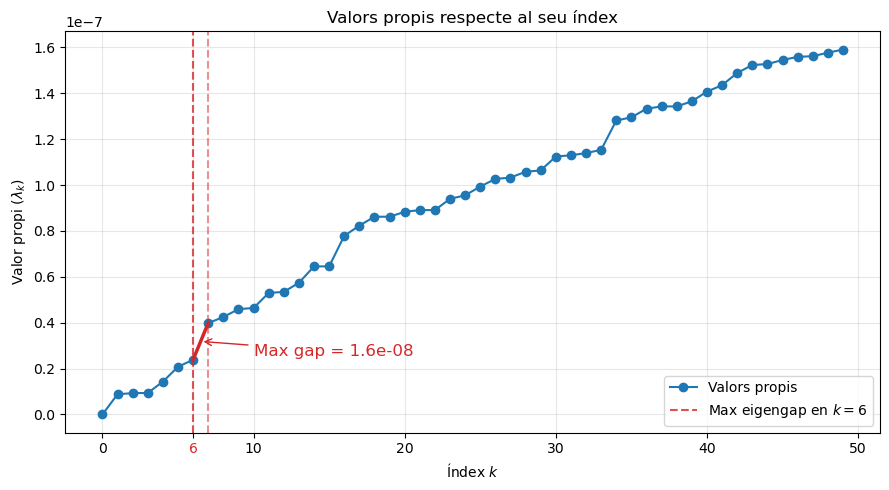

In [168]:
grafica_eigenvalues_vs_index(vaps, subfolder="autonom")

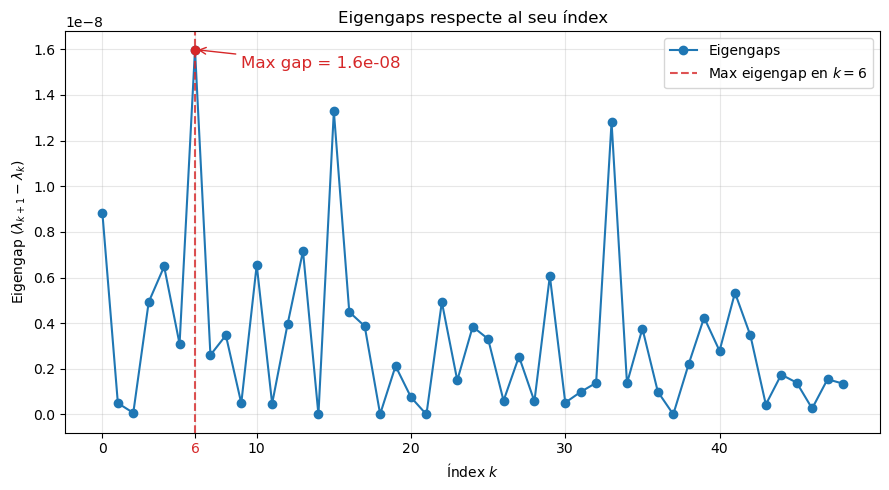

In [169]:
grafica_eigengaps_vs_index(vaps, subfolder="autonom")

In [170]:
num_clusters, diff_max = calcula_num_clusters_i_max_eigengap(vaps)

In [171]:
print(f"Nombre de clusters suggerit per l'heurística del màxim eigengap: {num_clusters}")
print(f"Valor del màxim eigengap: {diff_max:.3e}") # use scientific notation for small values

Nombre de clusters suggerit per l'heurística del màxim eigengap: 7
Valor del màxim eigengap: 1.598e-08


In [172]:
labels = troba_clusters(num_clusters, veps)

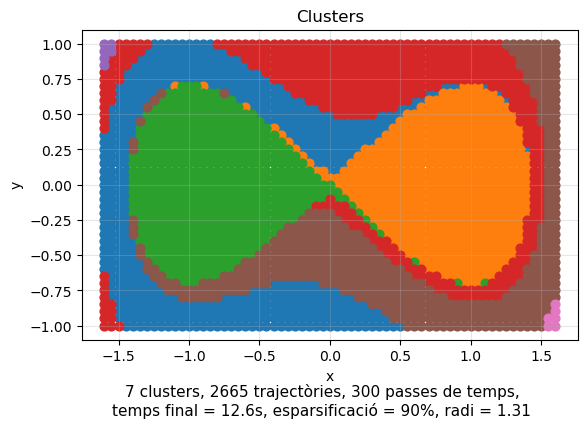

In [173]:
grafica_clusters(condicions_inicials, labels, num_clusters, sparsification_tol, 
                 sparsification_percent, t_steps, t_span, subfolder="autonom")

##### Opció B: triar radi d'esparsificació que maximitza la diferència màxima entre VAPs consecutius

In [178]:
plot_args = calcula_diffs_vs_radis(matriu_pesos, constant_diagonal, max_clusters, num_radis)
diffs, nums_clusters, radis, estadistics, sparsificacions, veps_llista = plot_args

In [179]:
indexs_max_rel = troba_indexs_max_rel(diffs)
print("indexs_max_rel =", indexs_max_rel)
print("radis[indexs_max_rel] =", radis[indexs_max_rel])

indexs_max_rel = [31, 35]
radis[indexs_max_rel] = [1.244 1.365]


Maxim_relatiu_num 1
Radi: 1.244, Esparsificació: 89.04%, Clusters: 16, Max Eigen gap: 1.98664e-08


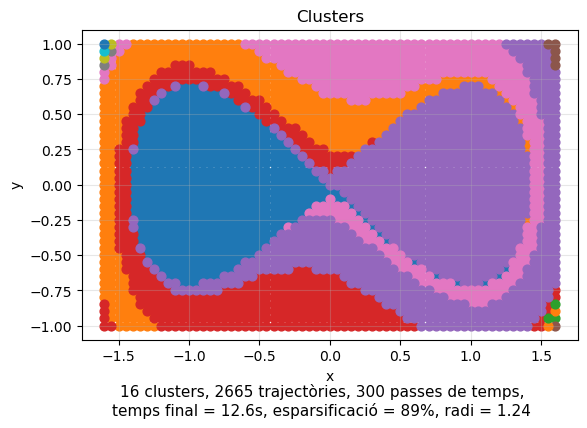

Maxim_relatiu_num 2
Radi: 1.365, Esparsificació: 90.82%, Clusters: 7, Max Eigen gap: 1.58637e-08


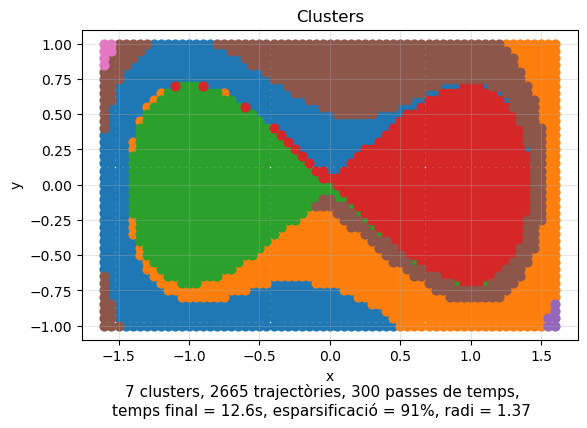

In [180]:
grafica_clusters_maxs_rel(indexs_max_rel, radis, sparsificacions, 
                          nums_clusters, diffs, veps_llista, condicions_inicials, 
                          t_steps, t_span, subfolder="autonom_maxs_rels")

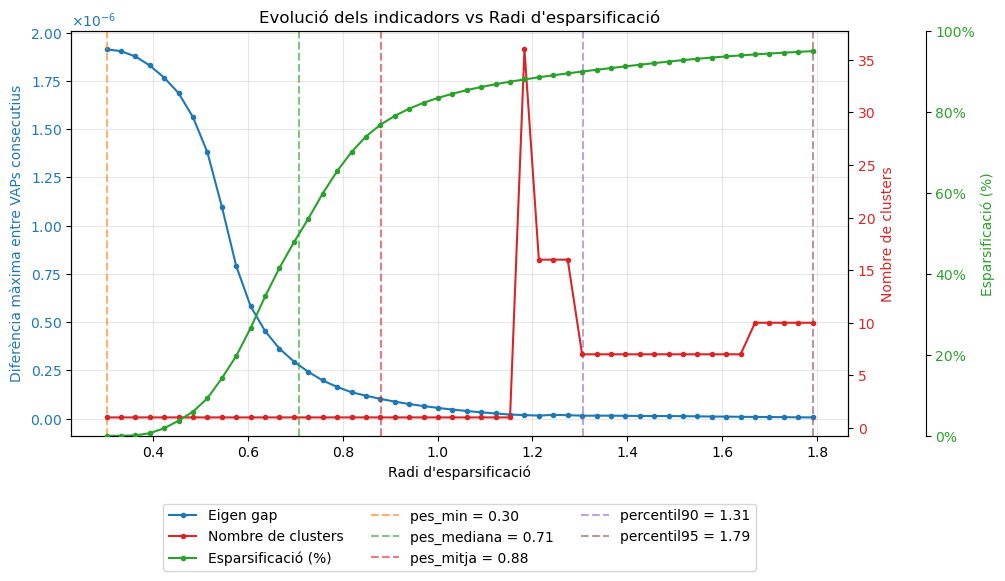

In [181]:
grafica_eigengaps_vs_radi(diffs, nums_clusters, radis, estadistics, sparsificacions, max_clusters, t_span, subfolder="autonom_maxs_rels")